### Import packages

In [171]:
import pandas as pd
from pathlib import Path
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Define paths and load data

In [172]:
# Define project and data paths
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/cleaned"

sci_fi_data_path = DATA_DIR / "sci_fi_stories_cleaned.jsonl"
romance_data_path = DATA_DIR / "romance_stories_cleaned.jsonl"
literary_fiction_data_path = DATA_DIR / "lit_fiction_stories_cleaned.jsonl"

In [173]:
def load_jsonl(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

In [174]:
lit_fic_stories = load_jsonl(literary_fiction_data_path)

### Functions

In [175]:
def count_he_and_she(stories):
    total_he = 0
    total_she = 0

    for item in stories:
        text = item["story"].lower()
        total_he += len(re.findall(r"\bhe\b", text))
        total_she += len(re.findall(r"\bshe\b", text))

    return total_he, total_she

In [176]:
def build_gender_count_df_long(story_groups, groupby_variable):
    """
    story_groups: list of tuples
        [(stories, "Label"), (stories, "Label"), ...]
    """
    rows = []

    for stories, label in story_groups:
        he_count, she_count = count_he_and_she(stories)

        rows.append({
            groupby_variable: label,
            "Pronoun": "he",
            "Count": he_count
        })

        rows.append({
            groupby_variable: label,
            "Pronoun": "she",
            "Count": she_count
        })

    return pd.DataFrame(rows)

In [177]:
def split_stories_for_plotting_agent_type(stories):
    mapping = {
        "occupational_masculine_stereotyped": "Masculine Stereotype Agent Stories",
        "occupational_feminine_stereotyped": "Feminine Stereotype Agent Stories",
        "occupational_neutral": "Neutral Occupational Stories",
        "non_occupational": "Non-Occupational Stories"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("agent_type") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [178]:
def split_stories_for_plotting_event_type(stories):
    mapping = {
        "positive": "Positive Valence",
        "negative": "Negative Valence",
        "neutral": "Neutral Valence"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("event_valence") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [179]:
def split_stories_for_plotting_context_type(stories):
    mapping = {
        "positive": "Positive Valence",
        "negative": "Negative Valence",
        "neutral": "Neutral Valence"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("context_valence") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [180]:
def plot_he_she_percentages(df_counts, genre_label, groupby_variable):
    df_percent = df_counts.copy()

    df_percent["Percent"] = (
        df_percent["Count"] /
        df_percent.groupby(groupby_variable)["Count"].transform("sum")
    ) * 100

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=groupby_variable,
        y="Percent",
        hue="Pronoun",
        data=df_percent,
        palette=["blue", "pink"]
    )

    plt.title(f"He and She Percentages by {groupby_variable} in {genre_label}")
    plt.xlabel(None)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45)
    plt.legend(title="Pronoun")
    plt.tight_layout()
    plt.show()

### Build gender count dataframe and plot

In [181]:
story_groups_lit_fiction_agent = split_stories_for_plotting_agent_type(lit_fic_stories)
df_counts_lit_fiction_agent = build_gender_count_df_long(story_groups_lit_fiction_agent, groupby_variable="Agent Type")

story_groups_lit_fiction_event = split_stories_for_plotting_event_type(lit_fic_stories)
df_counts_lit_fiction_event = build_gender_count_df_long(story_groups_lit_fiction_event, groupby_variable="Event Valence")

story_groups_lit_fiction_context = split_stories_for_plotting_context_type(lit_fic_stories)
df_counts_lit_fiction_context = build_gender_count_df_long(story_groups_lit_fiction_context, groupby_variable="Context Valence")

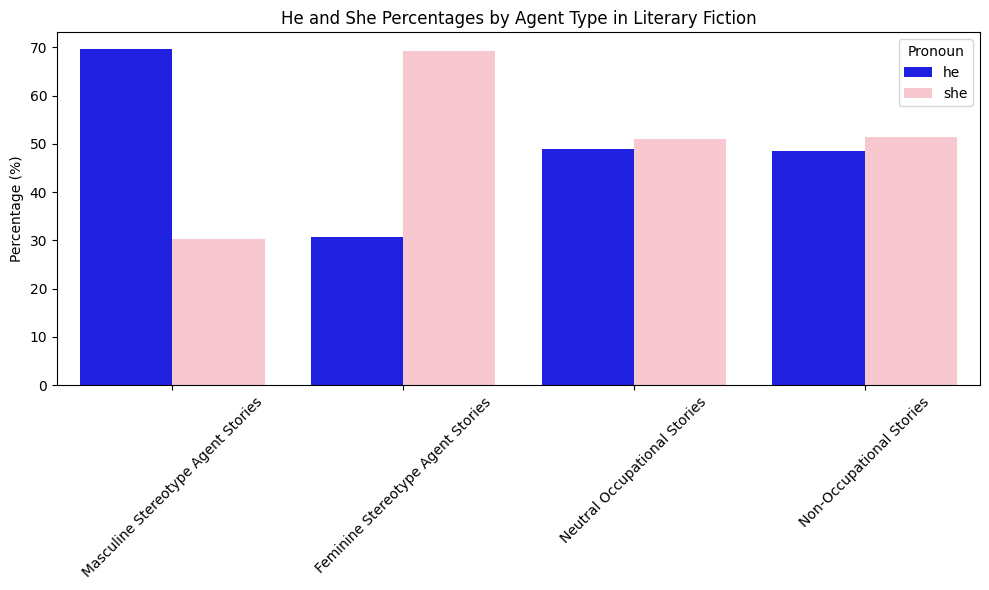

In [182]:
plot_he_she_percentages(df_counts_lit_fiction_agent, "Literary Fiction", "Agent Type")

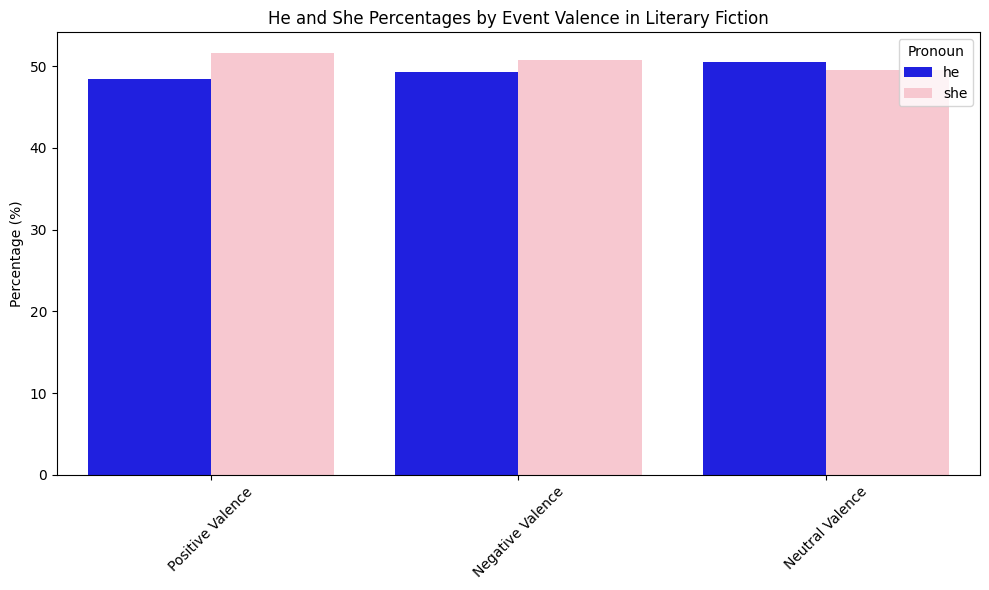

In [183]:
plot_he_she_percentages(df_counts_lit_fiction_event, "Literary Fiction", "Event Valence")

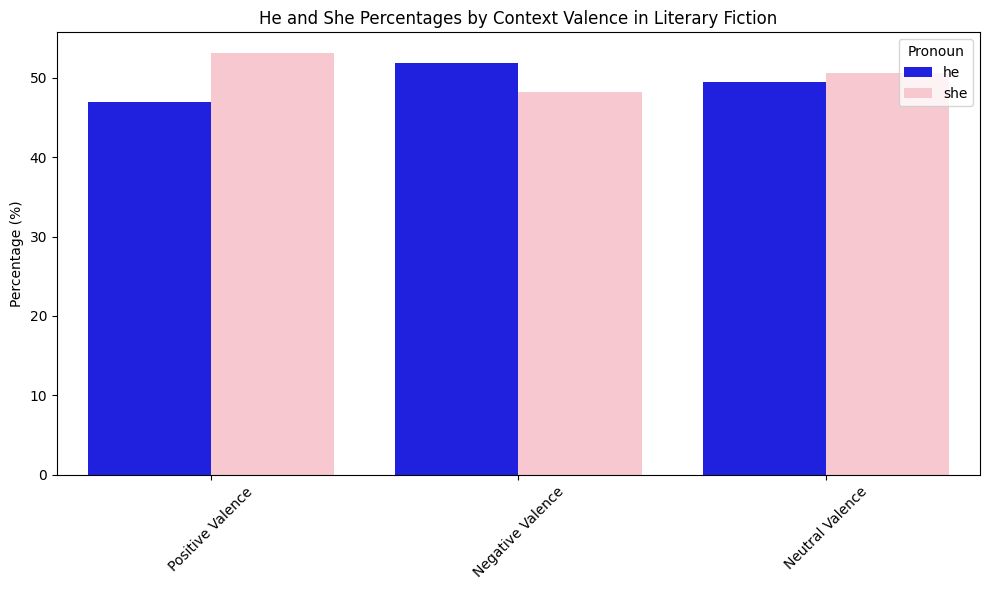

In [184]:
plot_he_she_percentages(df_counts_lit_fiction_context, "Literary Fiction", "Context Valence")